# Chapter 13: Vector Encoding

A central goal of this text is the quantum linear solve $A\mathbf{x}\propto\mathbf{b}$; this chapter
asks the first practical question: **how do we load a classical vector $\mathbf{b}$ into a quantum
computer?** Encoding is not a mere pre-processing detail — Aaronson cautioned that a quantum speedup
is contingent on an *efficient* data-loading mechanism, since a naive encoder can reintroduce $O(N)$
cost and erase the advantage. A unit vector $\mathbf{b}\in\mathbb{C}^{2^m}$ with $\|\mathbf{b}\|_2=1$
is interpreted as the amplitudes of an $m$-qubit state, $|b\rangle = b_0|0\cdots0\rangle + b_1|0\cdots1\rangle + \cdots$ — this is **amplitude encoding**.

The notebook develops a hierarchy of three strategies of increasing generality: (1) **hand-crafted
circuits** for vectors with recognizable structure (basis states, uniform superpositions, Walsh sign
patterns, entangled states) — optimal in gate count; (2) **PyEncode**, a library that automates
structured encoding for ten exact pattern families at $O(\mathrm{poly}(m))$ cost; and (3) the general
**Möttönen/Shende decomposition** — a binary tree of controlled $R_y$ rotations at $O(2^m)$ cost, the
algorithm behind Qiskit's `initialize`. The recurring lesson: encoding complexity is governed by the
*structure* of $\mathbf{b}$, not by the dimension $N=2^m$.

---

**Prerequisites:**
- See `Chapter02_QuantumSoftware.ipynb` for installation instructions

In [1]:
# Setup and imports
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import Statevector
from Chapter04_EngineeringProblems_functions import (truss2x2,truss3x2,truss2x3,truss3x3,truss_10bar,
                                                         PlaneStressCantilever)
from Chapter08_QuantumGates_functions import  (simulate_statevector,  simulate_measurements, 
                                              estimateCircuitGates, findActualHardwareRequirements)


from qiskit_aer.noise import NoiseModel, depolarizing_error
BASIS = ['cx', 'u', 'x', 'h', 'ry', 'rz', 'rx', 'p']   # transpilation basis

## Hand-crafting encoding circuits  *(Book §13.2, Examples 13.1-13.10)*

When $\mathbf{b}$ has simple structure, we can build an optimal circuit by hand. Set the `example`
variable to select a case:
1. **$e_0 = (1,0,\dots)$** — the default $|0\cdots0\rangle$; no gates needed.
2. **$e_1 = (0,1,0,\dots)$** — one $X$ on qubit 0: $|b\rangle = X_0|0\rangle^{\otimes m}$.
3. **Uniform superposition of two** — a Hadamard on qubit 0.
4. **Walsh (alternating signs)** — $X_0$ then $H^{\otimes m}$, giving $\tfrac1{\sqrt N}(1,-1,1,-1,\dots)$.
5. **Block sign pattern** — flip the *most significant* qubit $X_{m-1}$ before $H^{\otimes m}$.
6-8. **$R_y$ rotations** encode magnitudes; add $S$ for an imaginary component.
9. **Bell-like entangled state** $\tfrac1{\sqrt2}(|00\rangle-|11\rangle)$ — needs a CNOT.

Complex amplitudes are handled in two stages: $R_y$ for magnitudes, $R_z$ (or $S/S^\dagger$) for phases.

<IPython.core.display.Latex object>

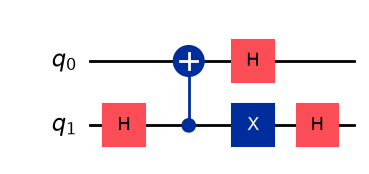

--- Circuit Analysis ---
Qubits: 2
Single-qubit gates: 3
CX/ECR gates: 1
Total gates: 4
Depth: 3
{'num_qubits': 2, 'single_gate_count': 3, 'cx_gates': 1, 'total_gates': 4, 'depth': 3, 'transpiled_circuit': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x00000151CCE38250>}


In [2]:
m = 2
N = 2**m

example = 9
qc = QuantumCircuit(m)
if (example == 1):
    pass # nothing to do
elif (example == 2):
    qc.x(0)
elif (example == 3):
    qc.h(range(m))
elif (example == 4):
    qc.x(0)
    qc.h(range(m))
elif (example == 5):
    qc.x(m-1)
    qc.h(range(m))
elif (example == 6):
    qc.ry(np.pi/3,0)
elif (example == 7):
    b = np.array([1/2, np.sqrt(3)/2])
    theta = 2*np.arctan(b[1]/b[0])
    qc.ry(theta,0)
elif (example == 8):
    theta = 2*np.arctan2(1/2, np.sqrt(3)/2) 
    qc.ry(theta, 0)
    qc.s(0)
elif (example == 9):
    qc.h(1)
    qc.cx(1, 0)
    qc.x(1)
    qc.h(range(2))


state = Statevector.from_instruction(qc)
display(state.draw("latex"))

qc.draw("mpl")
display(qc.draw("mpl"))

circuitData = estimateCircuitGates(qc)
print(circuitData)


## Structured encoding via PyEncode  *(Book §13.3)*

Hand-crafting is laborious and error-prone. **PyEncode** automates it for ten exact pattern families —
sparse, step, square, Walsh, Fourier, geometric, Hamming, staircase, Dicke, polynomial — mapping each
to a verified Qiskit circuit with *no vector materialization and no approximation*. Most patterns cost
$O(m)$ or $O(m^2)$ gates. Crucially, we do not build $\mathbf{b}$; we specify its mathematical
*structure*, and `encode` returns the circuit plus an `info` object (including the generating code).

### Walsh pattern  *(Book §13.3, Example 13.11)*

The alternating pattern $\mathbf{b}=\tfrac1{\sqrt N}(1,-1,1,-1,\dots)$ is a Walsh function. We request
it via `WALSH(k=0, c0=1, c1=-1)`; internally PyEncode emits exactly the hand-crafted recipe — an $X$
on qubit 0 followed by $H^{\otimes m}$.

# PyEncode — emitted circuit: WALSH k=0, c0=1.0, c1=-1.0 — period P=2^(k+1)=2
# m = 3 qubits,  N = 8 nodes
# Edit freely; run as standalone Qiskit code.

from qiskit import QuantumCircuit


m = 3
qc = QuantumCircuit(m, name='walsh')
qc.x(0)          # standard Walsh: X = R_y(pi)
for q in range(m):
    qc.h(q)


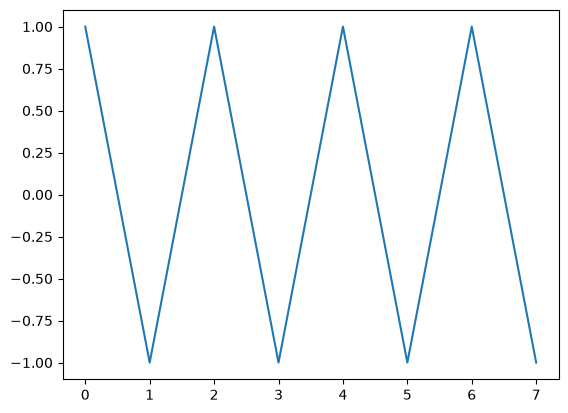

In [3]:
from pyencode import (encode, WALSH)
m = 3
N = 2**m
circuit, info = encode(WALSH(k=0, c0=1, c1=-1), N=N,validate=True)

print(info.circuit_code)
circuit.draw("mpl")
plt.plot(info.vector)

### Geometric pattern  *(Book §13.3, Example 13.12)*

The geometric pattern $\mathbf{b}=(1, r, r^2, r^3, \dots)$ with $r=0.5$ is a *product state*: each
qubit $j$ receives $R_y\!\big(2\arctan(r^{2^j})\big)$. Note that the vector PyEncode returns is not
necessarily normalized.

In [4]:
from pyencode import (encode, GEOMETRIC)
m = 3
N = 2**m
circuit, info = encode(GEOMETRIC(0.5), N=N,validate=True)

print(info.circuit_code)
print(info.vector)


# PyEncode — emitted circuit: GEOMETRIC  r=0.5, c=1.0
# m = 3 qubits,  N = 8 nodes
# Edit freely; run as standalone Qiskit code.

from qiskit import QuantumCircuit

import math

m = 3
r = 0.5
qc = QuantumCircuit(m, name='geometric')

# Product state: each qubit j gets R_y(2*arctan(r^(2^j)))
for j in range(m):
    theta_j = 2.0 * math.atan(r ** (2 ** j))
    qc.ry(theta_j, j)
[1.        0.5       0.25      0.125     0.0625    0.03125   0.015625
 0.0078125]


### Sparse pattern: point loads  *(Book §13.3)*

The most common structured right-hand side is a load applied at only a **few nodes**. Here unit loads
act at nodes 2 and 5 of an 8-node grid, i.e. $\mathbf{b}\propto e_2+e_5$. `SPARSE` takes a list of
`(index, amplitude)` pairs and applies the Gleinig–Hoefler algorithm at $O(s\,m)$ cost — independent
of $N$. Passing `validate=True` makes `encode` certify the circuit by statevector simulation and
populate `info.vector`.

PyEncode  v3.0.0
  Pattern     : SPARSE
  N           : 8  (m = 3 qubits)
  Gate count  : 4
  Complexity  : O(s·m)
  Validated   : yes
  Gates 1q/2q : 2 / 2
  Depth       : 3
  Success prob: 1.0
  Vector      : numpy array, shape (8,)
  Parameters  : {'loads': [{'k': 2, 'P': 1.0}, {'k': 5, 'P': 1.0}]}
  Circuit code: 366 chars (info.circuit_code)
vector: [0. 0. 1. 0. 0. 1. 0. 0.]


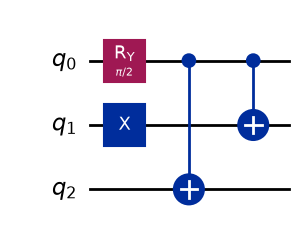

Text(0.5, 1.0, 'SPARSE: point loads at nodes 2 and 5')

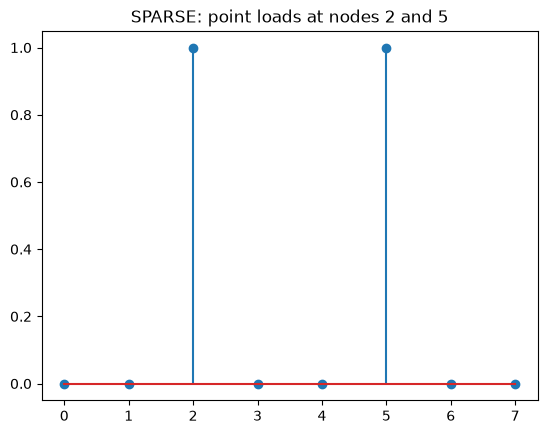

In [5]:
from pyencode import encode, SPARSE
m = 3
N = 2**m
circuit, info = encode(SPARSE([(2, 1.0), (5, 1.0)]), N=N, validate=True)

print(info)                       # pattern, gate count, complexity, validated
print('vector:', np.round(info.vector, 3))
display(circuit.draw('mpl'))
plt.figure(); plt.stem(info.vector); plt.title('SPARSE: point loads at nodes 2 and 5')

### Fourier pattern: a sinusoidal source  *(Book §13.3)*

Sinusoidal source terms pervade the discretised Poisson and heat equations, and they are exactly the
loads for which the QFT solver of Chapter 16 is most efficient. `FOURIER` prepares
$\sum_t A_t\sin(2\pi n_t i/N+\phi_t)$ via an inverse QFT at $O(m^2)$ cost. Each mode is a tuple
`(n, A, phi)` with **integer** frequency `n`. The full standalone source is available in
`info.circuit_code` (long for FOURIER, so we plot the vector instead).

FOURIER 9 O(m²)


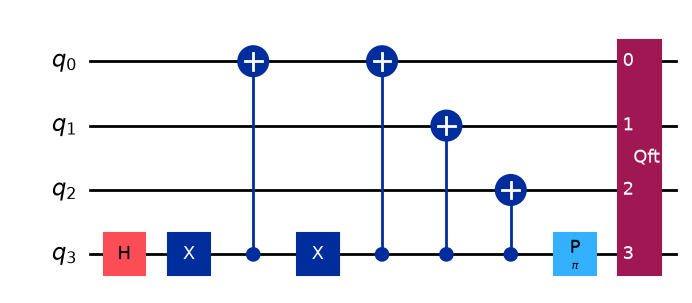

Text(0.5, 1.0, 'FOURIER: one sine period, sin(2*pi*i/N)')

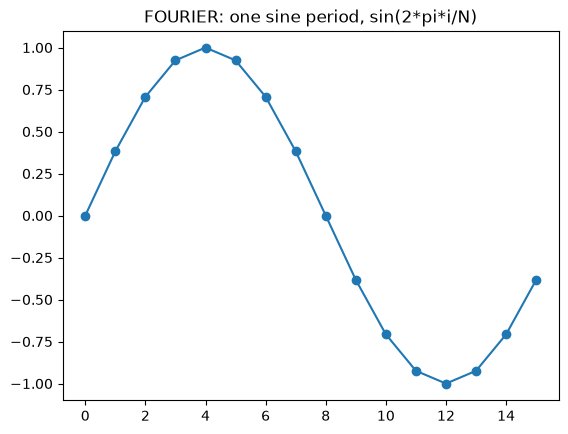

In [6]:
from pyencode import encode, FOURIER
m = 4
N = 2**m
circuit, info = encode(FOURIER(modes=[(1, 1.0, 0.0)]), N=N, validate=True)

print(info.pattern_name, info.gate_count, info.complexity)   # FOURIER 9 O(m^2)
display(circuit.draw('mpl'))
plt.figure(); plt.plot(info.vector, marker='o'); plt.title('FOURIER: one sine period, sin(2*pi*i/N)')

### Polynomial pattern: a parabolic profile  *(Book §13.3)*

A parabolic (Poiseuille) profile $f(x)=4x(1-x)$ on $x\in[0,1]$ is a degree-2 polynomial in the grid
coordinate. `POLYNOMIAL` takes the coefficient list $[c_0,c_1,\dots,c_d]$ of $f(x)=\sum_j c_j x^j$ and
(by default) evaluates on $x_i=i/(N-1)$. A degree-$d$ polynomial has a Walsh–Hadamard spectrum on
indices of Hamming weight $\le d$, so PyEncode loads that sparse spectrum and applies $H^{\otimes m}$
— exact, at $O(m^{d+1})$ cost.

POLYNOMIAL 22


Text(0.5, 1.0, 'POLYNOMIAL: parabolic profile')

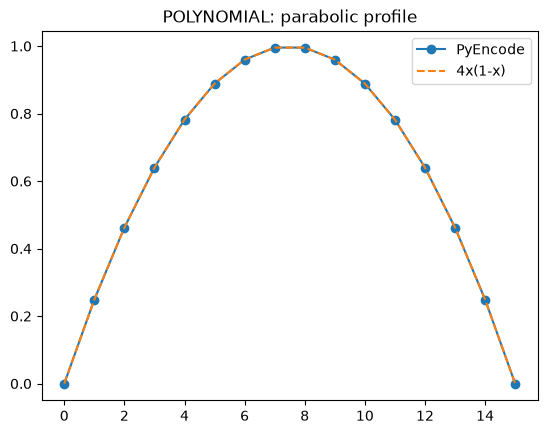

In [7]:
from pyencode import encode, POLYNOMIAL
m = 4
N = 2**m
# f(x) = 4x - 4x^2 = 4x(1-x)
circuit, info = encode(POLYNOMIAL([0.0, 4.0, -4.0]), N=N, validate=True)

print(info.pattern_name, info.gate_count)     # POLYNOMIAL 22
x = np.arange(N)/(N-1)
plt.figure(); plt.plot(info.vector, marker='o', label='PyEncode')
plt.plot(4*x*(1-x), '--', label='4x(1-x)'); plt.legend(); plt.title('POLYNOMIAL: parabolic profile')

### Composition: PARTITION for a piecewise-constant load  *(Book §13.3)*

PyEncode composes patterns with **disjoint support** into one state with no ancilla and success
probability exactly 1. Here a load is constant at value 1 on the first half of the domain and value 2
on the second half — two abutting `SQUARE` blocks. (For *overlapping* or weighted superpositions,
`SUM` is the general — LCU-based — alternative, whose success probability may be below 1.)

PARTITION gates= 13 p_succ= 1.0


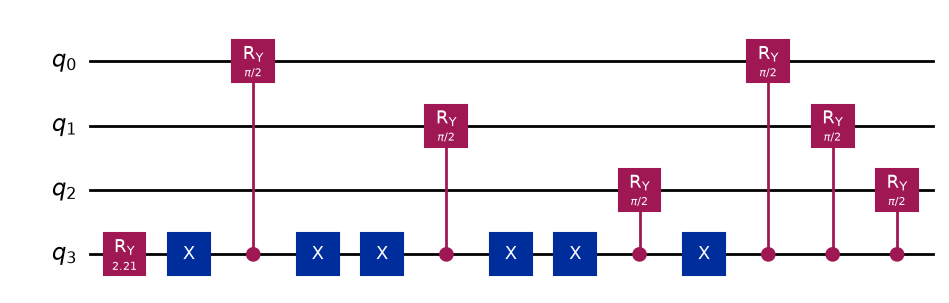

Text(0.5, 1.0, 'PARTITION: piecewise-constant load  (1 | 2)')

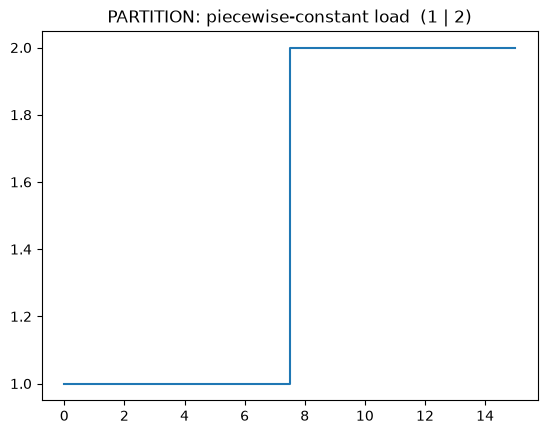

In [8]:
from pyencode import encode, PARTITION, SQUARE
m = 4
N = 2**m
circuit, info = encode(
    PARTITION([SQUARE(k_s=0, k_e=8,  c=1.0),
               SQUARE(k_s=8, k_e=16, c=2.0)]), N=N, validate=True)

print(info.pattern_name, 'gates=', info.gate_count, 'p_succ=', info.success_probability)
display(circuit.draw('mpl'))
plt.figure(); plt.step(range(N), info.vector, where='mid')
plt.title('PARTITION: piecewise-constant load  (1 | 2)')

### Reverse lookup: `match_vector`  *(Book §13.3)*

When we *have* a numerical vector and want to know which family fits it, `match_vector` scans the
catalog and ranks candidates **by fidelity**. We feed it the alternating-sign (Walsh) vector
$\mathbf{b}=\tfrac1{\sqrt N}(1,-1,1,-1,\dots)$ from §13.2. Note the ranking is by fidelity, *not* gate
count — read the whole table and pick the cheapest exact match. The returned `.pattern` is a
ready-to-use constructor for `encode`.

In [9]:
from pyencode import match_vector, print_matches
m = 3
N = 2**m
b = np.array([(-1)**k for k in range(N)], dtype=float) / np.sqrt(N)

matches = match_vector(b, top_k=3)
print_matches(matches)

best = matches[0]                      # cheapest exact match here is WALSH(k=0)
print('\nTop match:', best.pattern, ' gates=', best.gate_count)
circuit, info = encode(best.pattern, N=N, validate=True)   # re-encode from the recovered pattern
print('re-encoded:', info.pattern_name, info.gate_count, 'validated=', info.validated)

rank  pattern       rel_error   fidelity   gates  params
   1  WALSH         0.000e+00   1.000000       3  k=0, c0=0.3536, c1=-0.3536
   2  GEOMETRIC     0.000e+00   1.000000       3  r=-1, k_s=0, k_e=None, c=0.3536
   3  SPARSE        0.000e+00   1.000000      48  loads=[8 entries]

Top match: WALSH(k=0, c0=0.35355339059327373, c1=-0.35355339059327373)  gates= 3
re-encoded: WALSH 4 validated= True


### Approximate loading: `encode_mps`  *(Book §13.3)*

Many physical loads — a localized Gaussian bump, an exponential boundary layer — match no exact
family. The MPS loader compresses $\mathbf{b}$ to a bounded **bond dimension** $\chi$: larger $\chi$
means higher fidelity at higher gate cost. `info.params['truncation_error_sq']` upper-bounds the
fidelity loss, so you can dial $\chi$ to a target accuracy. This is the practical fallback, far cheaper
than the general $O(2^m)$ Möttönen/Shende algorithm for the smooth loads typical of physical problems.

Note the import path: `encode_mps` lives in the `pyencode.mps` submodule (not the top-level namespace).
It prints a short transpilation message while counting gates.

Transpiling MPS circuit for gate counts...
Transpiled gate counts: 5 1q gates, 0 2q gates; depth 1.
chi=1:  CX=  0  depth=  1  fidelity=0.50547
Transpiling MPS circuit for gate counts...
Transpiled gate counts: 32 1q gates, 13 2q gates; depth 27.
chi=2:  CX= 13  depth= 27  fidelity=0.99868
Transpiling MPS circuit for gate counts...
Transpiled gate counts: 136 1q gates, 78 2q gates; depth 154.
chi=4:  CX= 78  depth=154  fidelity=1.00000


Text(0.5, 1.0, 'Target Gaussian bump load (encode_mps, N=32)')

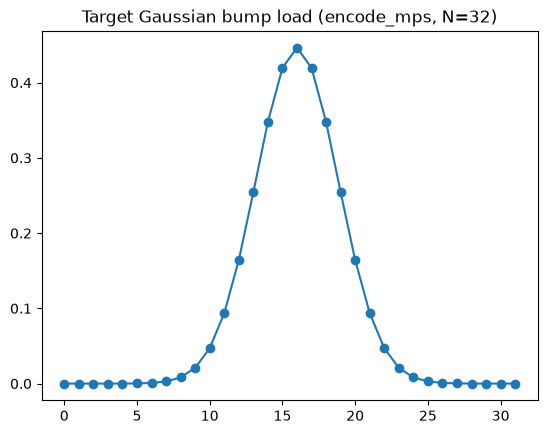

In [ ]:
from qiskit.quantum_info import Statevector
from pyencode import encode_mps  

m = 5
N = 2**m
i = np.arange(N)
b = np.exp(-((i - N/2)/4.0)**2); b /= np.linalg.norm(b)   # Gaussian bump load

for chi in [1, 2, 4]:
    qc, info = encode_mps(b, bond_dim=chi)
    sv = Statevector(qc).data.reshape(2**info.m, -1)[:, 0]
    fidelity = abs(np.vdot(b, sv/np.linalg.norm(sv)))**2
    print(f'chi={chi}:  CX={info.gate_count_2q:3d}  depth={info.circuit_depth:3d}  fidelity={fidelity:.5f}')

plt.figure(); plt.plot(b, marker='o'); plt.title('Target Gaussian bump load (encode_mps, N=32)')

## Qiskit's `initialize` on structured vectors  *(Book §13.2, §13.5)*

For comparison, we encode the same structured vectors from §13.2 with Qiskit's black-box `initialize`
(the Shende algorithm). Select `example` to build $\mathbf{b}$, normalize it, and let `initialize`
prepare the state. Unlike the hand-crafted circuits, `initialize` treats every vector as arbitrary —
we will see in §13.5 how much this costs for sparse inputs.

<IPython.core.display.Latex object>

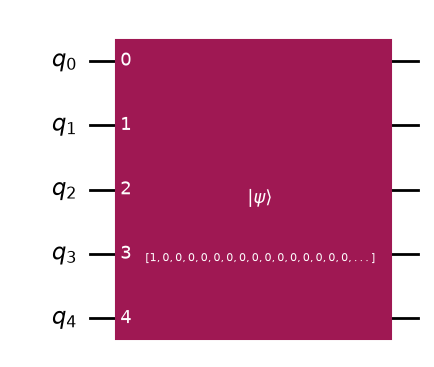

--- Circuit Analysis ---
Qubits: 5
Single-qubit gates: 5
CX/ECR gates: 0
Total gates: 5
Depth: 1
{'num_qubits': 5, 'single_gate_count': 5, 'cx_gates': 0, 'total_gates': 5, 'depth': 1, 'transpiled_circuit': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x00000151CED62F90>}


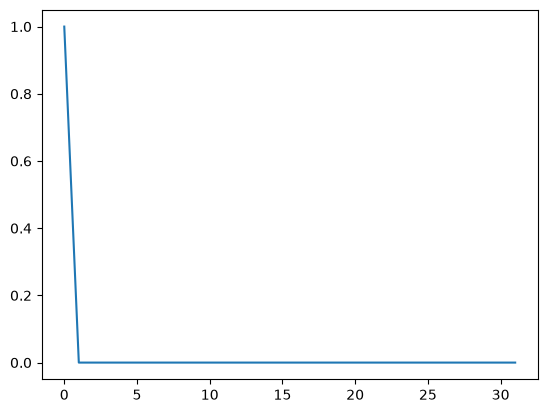

In [11]:
example = 1
if (example == 1):
    b = np.zeros(N)
    b[0] = 1
elif (example == 2):
    b = np.zeros(N)
    b[1] = 1
elif (example == 3):
    b = np.ones((N))
elif (example == 4):
    b = np.ones((N))
    b[1::2] = -1 # 1, 3 ... entries are negative
elif (example == 5):
    b = np.ones((N))
    b[N//2:] = -1 # second half of the entries are negative
elif (example == 6):
    b = np.zeros((N))
    b[0] = np.sqrt(3)/2 
    b[1] = 1/2
elif (example == 7):
    b = np.zeros((N))
    b[0] = np.sqrt(10)/5 
    b[1] = np.sqrt(15)/5 
elif (example == 8):
    b = np.zeros((N),dtype=complex)
    b[0] = np.sqrt(3)/2 
    b[1] = 1j/2
b = b/np.linalg.norm(b)

qc = QuantumCircuit(m)
qc.initialize(b, range(m))

state = Statevector.from_instruction(qc)
display(state.draw("latex"))

plt.plot(b.real, label="Real Part")
qc.draw("mpl")
display(qc.draw("mpl"))

circuitData = estimateCircuitGates(qc)
print(circuitData)  


## Transpiled circuit  *(Book §13.5)*

Transpiling the `initialize` circuit to the basis gate set and counting with `estimateCircuitGates`
lets us measure the real gate cost of general-purpose state preparation, to contrast against the
hand-crafted circuits above.

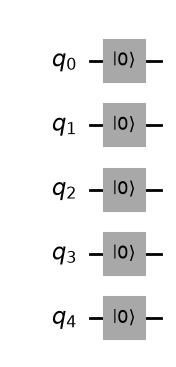

--- Circuit Analysis ---
Qubits: 5
Single-qubit gates: 5
CX/ECR gates: 0
Total gates: 5
Depth: 1
{'num_qubits': 5, 'single_gate_count': 5, 'cx_gates': 0, 'total_gates': 5, 'depth': 1, 'transpiled_circuit': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x00000151CEF6ED50>}


In [12]:
transpiled_circuit = transpile(qc, basis_gates=BASIS)
display(transpiled_circuit.draw("mpl"))
circuitData = estimateCircuitGates(transpiled_circuit)
print(circuitData)  

## Structured encoding (workspace)  *(Book §13.3)*

A scratch cell for experimenting with additional PyEncode patterns (e.g. STAIRCASE, GEOMETRIC, or the
SUM / PARTITION / TENSOR composition primitives). See the PyEncode documentation for the full catalog.

In [13]:
# Workspace: try other PyEncode patterns / composition primitives.
# Examples (uncomment one):

# from pyencode import encode, STAIRCASE
# circuit, info = encode(STAIRCASE(r=0.5), N=8, validate=True); print(info)

# from pyencode import encode, DICKE          # k-hot / fixed-weight initializer
# circuit, info = encode(DICKE(k=2), N=16, validate=True); print(info)

# from pyencode import encode, HAMMING        # amplitudes ~ r^{popcount(i)}, product state
# circuit, info = encode(HAMMING(r=0.5), N=64, validate=True); print(info)

# from pyencode import encode, TENSOR, WALSH, GEOMETRIC   # separable subregisters
# circuit, info = encode(TENSOR([(WALSH(k=0), 4), (GEOMETRIC(r=0.5), 4)]), N=16, validate=True)
# print(info); display(circuit.draw('mpl'))


## Möttönen decomposition: real amplitudes  *(Book §13.4, Example 13.13)*

For an arbitrary state with no exploitable structure we use the Möttönen/Shende decomposition, which
Qiskit's `initialize` implements. Consider
$|\psi\rangle = \sqrt{0.3}|00\rangle + \sqrt{0.1}|01\rangle + \sqrt{0.2}|10\rangle + \sqrt{0.4}|11\rangle$.
We encode it top-down through a binary tree of marginal probabilities:
- **Stage 1 (q1):** $P(q_1{=}0)=0.4$, so $R_y(\theta_1)$ with $\theta_1 = 2\arctan\!\sqrt{0.6/0.4}$.
- **Stage 2 (q0):** two *controlled* $R_y$ rotations, one per branch of q1, splitting each marginal
  into its two children.

<IPython.core.display.Latex object>

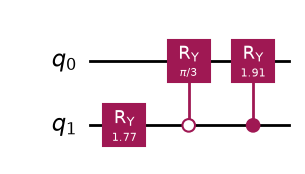

In [14]:
# psi = [np.sqrt(0.3), np.sqrt(0.1), np.sqrt(0.2), np.sqrt(0.4)]

# Total prob for q1=0 is 0.4, for q1=1 is 0.6
theta_1 = 2 * np.arctan2(np.sqrt(0.6), np.sqrt(0.4))

# If q1=0, split 0.4 into 0.3 and 0.1
theta_00 = 2 * np.arctan2(np.sqrt(0.1), np.sqrt(0.3))

# If q1=1, split 0.6 into 0.2 and 0.4
theta_10 = 2 * np.arctan2(np.sqrt(0.4), np.sqrt(0.2))

qc = QuantumCircuit(2)
qc.ry(theta_1, 1)
qc.cry(theta_00, 1, 0, ctrl_state='0')
qc.cry(theta_10, 1, 0, ctrl_state='1') 

state = Statevector.from_instruction(qc)
display(state.draw('latex'))
display(qc.draw('mpl'))

## Möttönen decomposition: complex amplitudes  *(Book §13.4, Example 13.14)*

Now $|\psi\rangle = \sqrt{0.3}|00\rangle + i\sqrt{0.2}|01\rangle + \sqrt{0.1}|10\rangle - i\sqrt{0.4}|11\rangle$.
The magnitude tree (the $R_y$ layer) is identical to the real case. The phases are then imprinted by a
final layer of controlled $S$ and $S^\dagger$ gates — exact quarter-turn phase gates ($S=\mathrm{diag}(1,i)$,
$S^\dagger=\mathrm{diag}(1,-i)$) with no global-phase ambiguity — placing the $+i$ on $|01\rangle$ and
$-i$ on $|11\rangle$. Just 5 gates in total.

<IPython.core.display.Latex object>

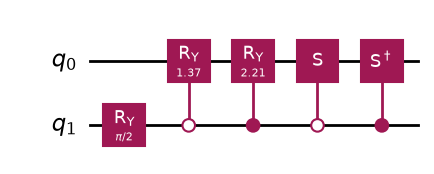

In [15]:
# Level 1 & 2: magnitude tree (identical to real-amplitude example)
theta_1  = np.pi/2
theta_00 = 2*np.arctan2(np.sqrt(0.2), np.sqrt(0.3))   # ~1.352 rad
theta_10 = 2*np.arctan2(np.sqrt(0.4), np.sqrt(0.1))   # ~2.214 rad

qc = QuantumCircuit(2)
qc.ry(theta_1,  1)
qc.cry(theta_00, 1, 0, ctrl_state='0')   # left branch
qc.cry(theta_10, 1, 0, ctrl_state='1')   # right branch

# Level 3: phase layer using S and Sdg (no global phase ambiguity)
# |01>: phase +i -> controlled-S on q0, active when q1=0 and q0=1
qc.cs(1, 0, ctrl_state='0')              # S on q0 controlled on q1=0

# |11>: phase -i -> controlled-Sdg on q0, active when q1=1 and q0=1
qc.csdg(1, 0, ctrl_state='1')           # Sdg on q0 controlled on q1=1
state = Statevector.from_instruction(qc)
display(state.draw('latex'))
display(qc.draw('mpl'))

## Möttönen decomposition: three qubits  *(Book §13.4, Example 13.15)*

For three qubits the tree gains a third level. Probability is split first over q2, then over q1
conditioned on q2, then over q0 conditioned on both. Each level *doubles* the number of controlled
rotations: 1, then 2, then 4 — a total of $\sum_{k=1}^{3} 2^{k-1} = 2^3 - 1 = 7$ gates. In general
level $k$ needs $2^{k-1}$ controlled $R_y$ rotations, giving $2^m-1$ gates — the $O(N)$ cost of
general state preparation.

<IPython.core.display.Latex object>

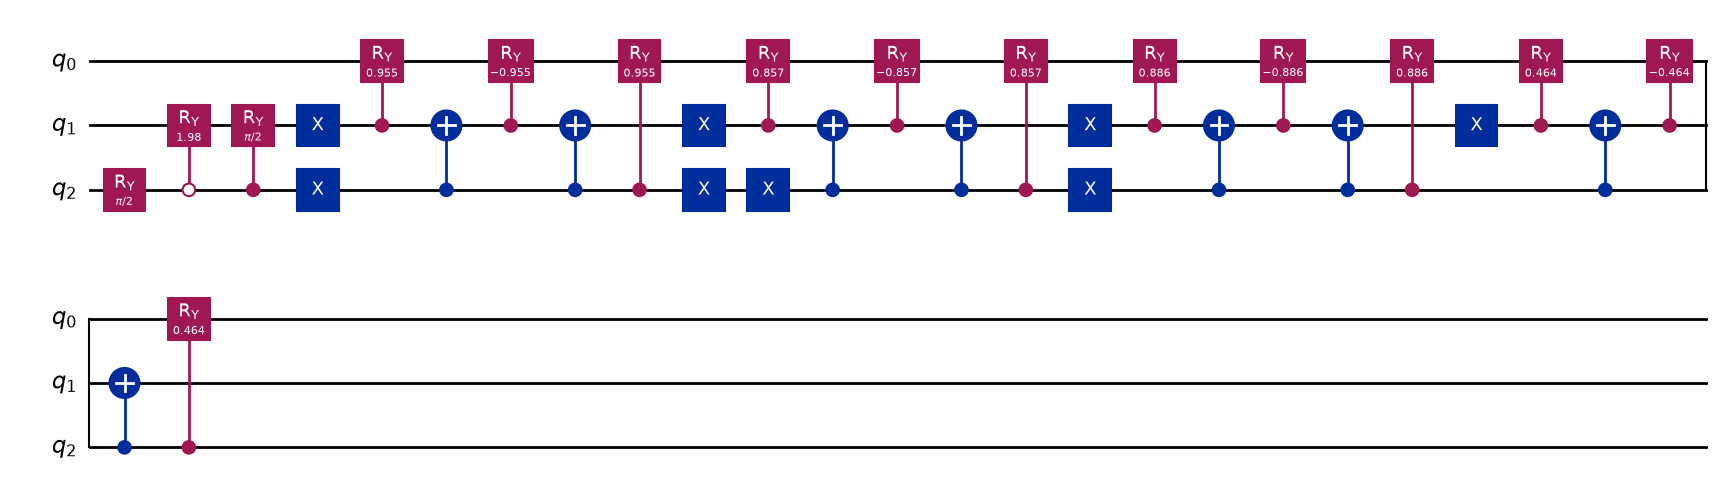

In [16]:
p = [0.05, 0.10, 0.15, 0.20, 0.10, 0.15, 0.20, 0.05]

# Level 1: q2
theta_2   = 2*np.arctan2(np.sqrt(0.50), np.sqrt(0.50))   # ~1.571

# Level 2: q1 | q2
theta_02  = 2*np.arctan2(np.sqrt(p[2]+p[3]), np.sqrt(p[0]+p[1]))  # q2=0
theta_12  = 2*np.arctan2(np.sqrt(p[6]+p[7]), np.sqrt(p[4]+p[5]))  # q2=1

# Level 3: q0 | q2,q1
theta_002 = 2*np.arctan2(np.sqrt(p[1]), np.sqrt(p[0]))   # q2=0, q1=0
theta_012 = 2*np.arctan2(np.sqrt(p[3]), np.sqrt(p[2]))   # q2=0, q1=1
theta_102 = 2*np.arctan2(np.sqrt(p[5]), np.sqrt(p[4]))   # q2=1, q1=0
theta_112 = 2*np.arctan2(np.sqrt(p[7]), np.sqrt(p[6]))   # q2=1, q1=1

qc = QuantumCircuit(3)
qc.ry(theta_2,  2)                              # level 1
qc.cry(theta_02, 2, 1, ctrl_state='0')          # level 2: q2=0
qc.cry(theta_12, 2, 1, ctrl_state='1')          # level 2: q2=1

# level 3: doubly-controlled Ry via standard decomposition
# ccry(theta, ctrl1, ctrl2, tgt) uses X gates to handle ctrl_state
def ccry(qc, theta, ctrl1, ctrl2, tgt, c1_state='1', c2_state='1'):
    """
    Apply a doubly-controlled R_y(theta) using the standard 2-CX decomposition.

    Realizes a Toffoli-style controlled rotation without an ancilla by splitting
    R_y(theta) into three controlled R_y(±theta/2) rotations interleaved with two
    CX gates. Requested control states are handled by conjugating the relevant
    control qubit with X gates, so any combination of 0/1 control values is
    supported. This builds the third level of the amplitude-encoding tree.

    Parameters
    ----------
    qc : qiskit.QuantumCircuit
        Circuit the gates are appended to, in place.
    theta : float
        Rotation angle applied to the target when both controls are active.
    ctrl1, ctrl2 : int
        Indices of the two control qubits.
    tgt : int
        Index of the target qubit receiving the R_y rotation.
    c1_state, c2_state : str, optional
        Desired activation state ('0' or '1') of ctrl1 and ctrl2 respectively.
        A '0' wraps that control in X gates. Both default to '1'.

    Returns
    -------
    None
        The gates are added to ``qc`` as a side effect.
    """
    if c1_state == '0': qc.x(ctrl1)
    if c2_state == '0': qc.x(ctrl2)
    qc.cry(theta/2,  ctrl2, tgt)
    qc.cx(ctrl1, ctrl2)
    qc.cry(-theta/2, ctrl2, tgt)
    qc.cx(ctrl1, ctrl2)
    qc.cry(theta/2,  ctrl1, tgt)
    if c1_state == '0': qc.x(ctrl1)
    if c2_state == '0': qc.x(ctrl2)

ccry(qc, theta_002, 2, 1, 0, '0', '0')         # q2=0, q1=0
ccry(qc, theta_012, 2, 1, 0, '0', '1')         # q2=0, q1=1
ccry(qc, theta_102, 2, 1, 0, '1', '0')         # q2=1, q1=0
ccry(qc, theta_112, 2, 1, 0, '1', '1')         # q2=1, q1=1
state = Statevector.from_instruction(qc)
display(state.draw('latex'))
display(qc.draw('mpl'))

## Preparing a Bell state via the tree  *(Book §13.4)*

A quick specialization: preparing $\tfrac1{\sqrt2}(|00\rangle+|11\rangle)$ with an $H$ on q1 followed
by a single controlled $R_y$ (active when q1 $=1$) — showing how the entangled Bell state falls
straight out of the intermediate-state / controlled-rotation building block.

1.5707963267948966 1.369438406004566 3.141592653589793
Resulting Statevector:


<IPython.core.display.Latex object>

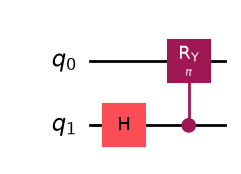

In [17]:
theta_10 = 2*np.arctan2(1, 0)
qc = QuantumCircuit(2)
qc.h( 1)
qc.cry(theta_10, 1, 0, ctrl_state='1') 


# results
print(theta_1,theta_00, theta_10)
state = Statevector.from_instruction(qc)
print("Resulting Statevector:")
display(state.draw('latex'))
display(qc.draw('mpl'))

## Möttönen, three qubits: a second example  *(Book §13.4, Example 13.15)*

The same three-level construction applied to a different probability distribution
$p = (0.05, 0.10, 0.15, 0.10, 0.20, 0.15, 0.10, 0.15)$. The level-1 rotation on q2 uses the marginals
$P(q_2{=}0)=0.40$, $P(q_2{=}1)=0.60$; the level-2 and level-3 controlled $R_y$ angles are read off the
conditional splits exactly as before.

Resulting Statevector:


<IPython.core.display.Latex object>

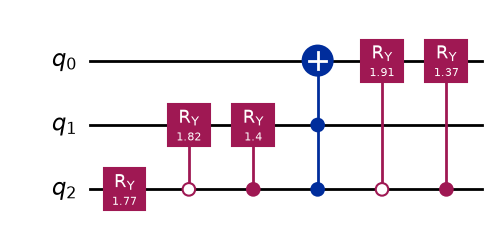

In [18]:

p = [0.05, 0.10, 0.15, 0.10, 0.20, 0.15, 0.10, 0.15]

# Level 1
theta_2   = 2*np.arctan2(np.sqrt(0.60), np.sqrt(0.40))
# Level 2
theta_02  = 2*np.arctan2(np.sqrt(0.25), np.sqrt(0.15))
theta_12  = 2*np.arctan2(np.sqrt(0.25), np.sqrt(0.35))
# Level 3
theta_002 = 2*np.arctan2(np.sqrt(p[1]), np.sqrt(p[0]))
theta_012 = 2*np.arctan2(np.sqrt(p[3]), np.sqrt(p[2]))
theta_102 = 2*np.arctan2(np.sqrt(p[5]), np.sqrt(p[4]))
theta_112 = 2*np.arctan2(np.sqrt(p[7]), np.sqrt(p[6]))

qc = QuantumCircuit(3)
# Level 1: rotate q2
qc.ry(theta_2, 2)
# Level 2: rotate q1 conditioned on q2
qc.cry(theta_02, 2, 1, ctrl_state='0')
qc.cry(theta_12, 2, 1, ctrl_state='1')
# Level 3: rotate q0 conditioned on (q2, q1)
qc.ccx(2, 1, 0)  # placeholder: see note below
qc.cry(theta_002, 2, 0, ctrl_state='0')  
qc.cry(theta_012, 2, 0, ctrl_state='1') 

state = Statevector.from_instruction(qc)
print("Resulting Statevector:")
display(state.draw('latex'))
display(qc.draw('mpl'))

## Cost of ignoring structure: `initialize` vs. hand-crafted  *(Book §13.5, Table 13.1)*

Qiskit's `initialize` (Shende) prepares any $m$-qubit state at $O(2^m)$ gate cost. Here we apply it to
each structured vector from §13.2 and count gates after decomposition to `u/cx` at optimization level 3,
for $m=10$ ($N=1024$). The lesson (Table 13.1): `initialize` exploits *separability* — the uniform
superposition and Walsh pattern cost only $\approx 2m$ gates — but **not sparsity**: single-entry
vectors $e_1$, the two-component $R_y$ state, and the two-entry entangled state each blow up to over
1000 gates, versus 1-2 hand-crafted. This gap motivates using PyEncode (or a hand-crafted circuit)
whenever $\mathbf{b}$ has recognizable structure.

In [19]:
from Chapter13_VectorEncoding_functions import gate_count

m = 10  # change this to any value
N = 2**m
print(f"Number of qubits (m): {m}")
# 1. Computational basis state e_0
b = np.zeros(N); b[0] = 1.0
print("e_0:                  ", gate_count(b, m))

# 2. Computational basis state e_1
b = np.zeros(N); b[1] = 1.0
print("e_1:                  ", gate_count(b, m))

# 3. Uniform superposition of first two states
b = np.zeros(N)
b[0] = 1/np.sqrt(2); b[1] = 1/np.sqrt(2)
print("Superposition 2:      ", gate_count(b, m))

# 4. Two-component real state (Ry rotation on qubit 0)
b = np.zeros(N)
b[0] = np.sqrt(3)/2; b[1] = 1/2
print("Two-component (Ry):   ", gate_count(b, m))

# 5. Uniform superposition (H^{otimes m})
b = np.ones(N) / np.sqrt(N)
print("Uniform superposition:", gate_count(b, m))

# 6. Alternating sign pattern (Walsh, X on qubit 0)
b = np.array([(-1)**k for k in range(N)],
             dtype=float) / np.sqrt(N)
print("Walsh alternating:    ", gate_count(b, m))

# 7. Block sign pattern (X on qubit m-1)
b = np.array([1.0]*(N//2) + [-1.0]*(N//2)) / np.sqrt(N)
print("Block sign:           ", gate_count(b, m))

# 8. Entangled state (Ry + CNOT), nonzero at indices 0 and N-1
b = np.zeros(N)
b[0] = np.sqrt(10)/5; b[N-1] = np.sqrt(15)/5
print("Entangled (Ry+CNOT):  ", gate_count(b, m))



Number of qubits (m): 10
e_0:                   (OrderedDict([('reset', 10)]), 10)
e_1:                   (OrderedDict([('u', 512), ('cx', 511), ('reset', 10)]), 1033)
Superposition 2:       (OrderedDict([('u', 512), ('cx', 511), ('reset', 10)]), 1033)
Two-component (Ry):    (OrderedDict([('u', 512), ('cx', 511), ('reset', 10)]), 1033)
Uniform superposition: (OrderedDict([('reset', 10), ('u', 10)]), 20)
Walsh alternating:     (OrderedDict([('reset', 10), ('u', 10)]), 20)
Block sign:            (OrderedDict([('u', 11), ('reset', 10), ('cx', 9)]), 30)
Entangled (Ry+CNOT):   (OrderedDict([('u', 1023), ('cx', 1013), ('reset', 10)]), 2046)
